### CatBoost was selected as the final deployment model due to its balanced performance across evaluation metrics, achieving the highest F1-score and recall among the compared models. This notebook presents the training, interpretation, and deployment preparation of the final CatBoost classifier.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Importing our dataset

In [2]:
df = pd.read_csv('diabetes_clean.csv')
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35      125  33.6   
1            1       85             66             29      125  26.6   
2            8      183             64             29      125  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# Feature Preparation

In [3]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Stratified 5-Fold Cross-Validation Setup

In [4]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

## CatBoost Classifier — Hyperparameter Configuration

In [5]:
from catboost import CatBoostClassifier
cb_model = CatBoostClassifier(iterations=300,learning_rate=0.05,depth=6,l2_leaf_reg=3,random_seed=42,verbose=0)
print(cb_model)

CatBoostClassifier(depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.05, random_seed=42, verbose=0)


In [6]:
cb_accuracy = cross_val_score(cb_model,X,y,cv=skf,scoring='accuracy')
cb_recall = cross_val_score(cb_model,X,y,cv=skf,scoring='recall')
cb_precision = cross_val_score(cb_model,X,y,cv=skf,scoring='precision')
cb_f1 = cross_val_score(cb_model,X,y,cv=skf,scoring='f1')
cb_auc = cross_val_score(cb_model,X,y,cv=skf,scoring='roc_auc')

print("Accuracy:", cb_accuracy)
print("Recall:", cb_recall)
print("Precision:", cb_precision)
print("F1:", cb_f1)
print("ROC-AUC:", cb_auc)

Accuracy: [0.77922078 0.76623377 0.77272727 0.75163399 0.74509804]
Recall: [0.68518519 0.57407407 0.64814815 0.60377358 0.58490566]
Precision: [0.68518519 0.70454545 0.68627451 0.65306122 0.64583333]
F1: [0.68518519 0.63265306 0.66666667 0.62745098 0.61386139]
ROC-AUC: [0.84537037 0.83981481 0.82333333 0.82396226 0.7845283 ]


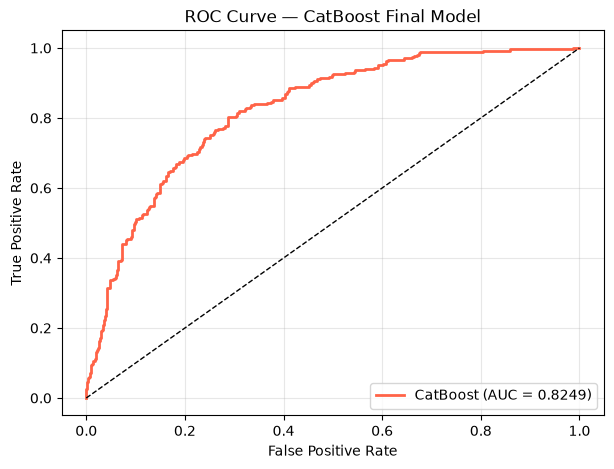

In [7]:
from sklearn.metrics import roc_curve, auc

cb_proba = cross_val_predict(cb_model, X, y, cv=skf, method='predict_proba')[:,1]
fpr, tpr, _ = roc_curve(y, cb_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'CatBoost (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — CatBoost Final Model')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.savefig('roc_catboost.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
print("\n===== CatBoost Summary =====")

print(f"Accuracy : {cb_accuracy.mean():.4f} ± {cb_accuracy.std():.4f}")
print(f"Recall   : {cb_recall.mean():.4f} ± {cb_recall.std():.4f}")
print(f"Precision: {cb_precision.mean():.4f} ± {cb_precision.std():.4f}")
print(f"F1-Score : {cb_f1.mean():.4f} ± {cb_f1.std():.4f}")
print(f"ROC-AUC  : {cb_auc.mean():.4f} ± {cb_auc.std():.4f}")


===== CatBoost Summary =====
Accuracy : 0.7630 ± 0.0128
Recall   : 0.6192 ± 0.0416
Precision: 0.6750 ± 0.0221
F1-Score : 0.6452 ± 0.0265
ROC-AUC  : 0.8234 ± 0.0213


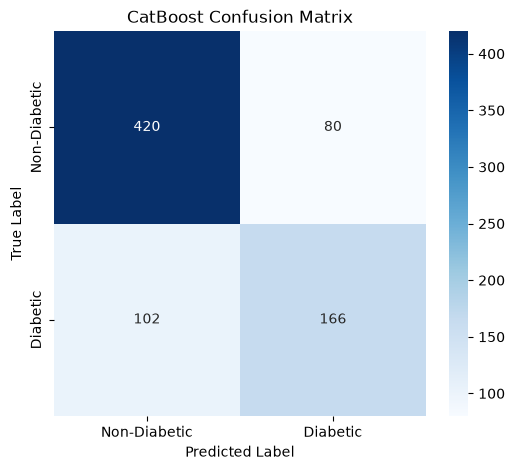

In [9]:
plt.figure(figsize=(6,5))
cb_pred = cross_val_predict(cb_model,X,y,cv=skf)
cb_cm = confusion_matrix(y, cb_pred)
sns.heatmap(cb_cm,annot=True,fmt='d',cmap='Blues',
    xticklabels=['Non-Diabetic','Diabetic'],
    yticklabels=['Non-Diabetic','Diabetic']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("CatBoost Confusion Matrix")

plt.show()

# Train on Full Dataset

In [10]:
cb_model.fit(X, y)

CatBoostClassifier(depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.05, random_seed=42, verbose=0)

# Feature Importance

In [11]:
importance = cb_model.get_feature_importance()

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance',ascending=False)

feature_importance

,Feature,Importance
1,Glucose,21.334976
5,BMI,18.617657
6,DiabetesPedigreeFunction,13.619885
7,Age,12.578042
0,Pregnancies,10.313306
2,BloodPressure,9.156989
4,Insulin,8.060655
3,SkinThickness,6.318490


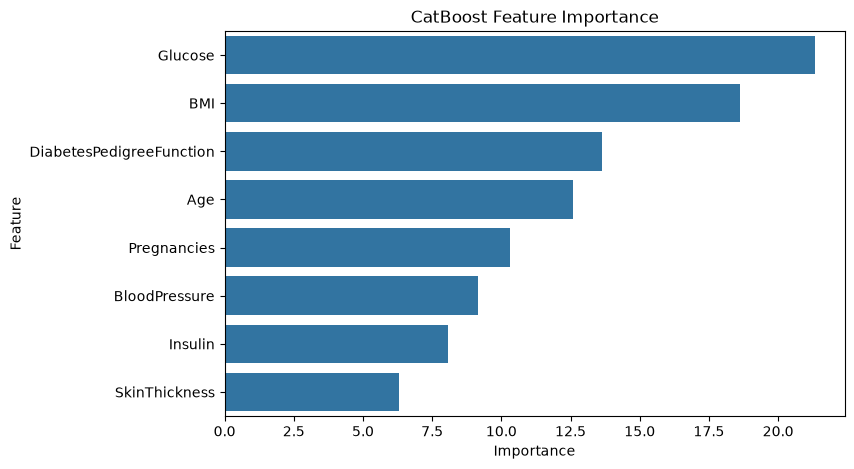

In [12]:
plt.figure(figsize=(8,5))
sns.barplot(data=feature_importance,x='Importance',y='Feature')
plt.title("CatBoost Feature Importance")
plt.show()

# SHAP Explanation

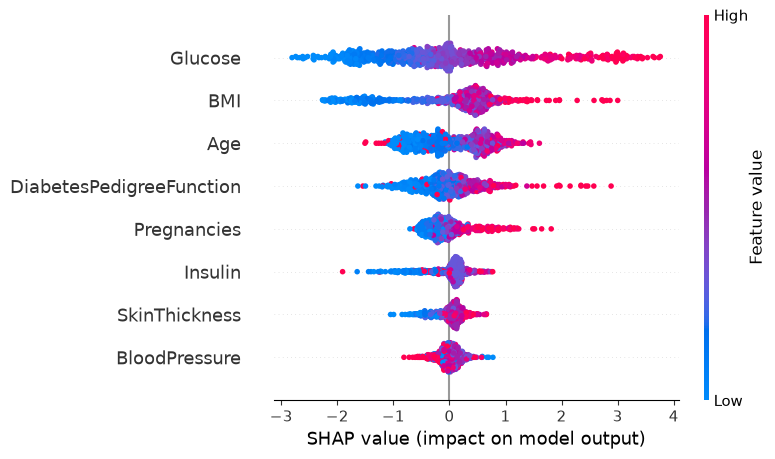

In [13]:
import shap

explainer = shap.TreeExplainer(cb_model)
shap_values = explainer.shap_values(X)
shap.summary_plot(shap_values,X)

# Model saved

In [14]:
import joblib
import os

os.makedirs("models", exist_ok=True)
joblib.dump(cb_model, "models/catboost_final.pkl")

print("Model saved successfully!")

Model saved successfully!


# Test with Manual Inputs

In [15]:
loaded_model = joblib.load("models/catboost_final.pkl")

In [16]:
print("""
Enter values in these ranges:

Pregnancies            : 0 – 17
Glucose                : 44 – 199 mg/dL
Blood Pressure         : 24 – 122 mm Hg
Skin Thickness         : 7 – 99 mm
Insulin                : 14 – 846 μU/mL
BMI                    : 18.2 – 67.1 kg/m²
Diabetes Pedigree Func : 0.078 – 2.42
Age                    : 21 – 81 years
""")

pregnancies = float(input("Pregnancies: "))
glucose     = float(input("Glucose: "))
bp          = float(input("Blood Pressure: "))
skin        = float(input("Skin Thickness: "))
insulin     = float(input("Insulin: "))
bmi         = float(input("BMI: "))
dpf         = float(input("Diabetes Pedigree Function: "))
age         = float(input("Age: "))

if glucose == 0:
    glucose = X['Glucose'].median()

if bp == 0:
    bp = X['BloodPressure'].median()

if skin == 0:
    skin = X['SkinThickness'].median()

if insulin == 0:
    insulin = X['Insulin'].median()

if bmi == 0:
    bmi = X['BMI'].median()

sample = np.array([[
    pregnancies,
    glucose,
    bp,
    skin,
    insulin,
    bmi,
    dpf,
    age
]])


prediction = cb_model.predict(sample)
probability = cb_model.predict_proba(sample)

confidence = max(probability[0]) * 100
print("\n===== Prediction Result =====")

if prediction[0] == 1:
    print("Result    : DIABETIC")
else:
    print("Result    : NON-DIABETIC")

print(f"Confidence: {max(probability[0]) * 100:.1f}%")

print("\nClass Probabilities:")
print(f"Non-Diabetic : {probability[0][0] * 100:.1f}%")
print(f"Diabetic     : {probability[0][1] * 100:.1f}%")

if confidence >= 80:
    print("\nAssessment : High confidence prediction.")
elif confidence >= 60:
    print("\nAssessment : Moderate confidence prediction.")
else:
    print("\n Assessment : Borderline prediction.")
    print("Note: The model is uncertain in this case.")
    print("This prediction should be interpreted cautiously.")


Enter values in these ranges:

Pregnancies            : 0 – 17
Glucose                : 44 – 199 mg/dL
Blood Pressure         : 24 – 122 mm Hg
Skin Thickness         : 7 – 99 mm
Insulin                : 14 – 846 μU/mL
BMI                    : 18.2 – 67.1 kg/m²
Diabetes Pedigree Func : 0.078 – 2.42
Age                    : 21 – 81 years



ValueError: could not convert string to float: ''

In [ ]:
shap_dict = dict(zip(X.columns,shap_values[0]))

In [ ]:
sorted_shap = sorted(
    shap_dict.items(),
    key=lambda x: abs(x[1]),
    reverse=True
)

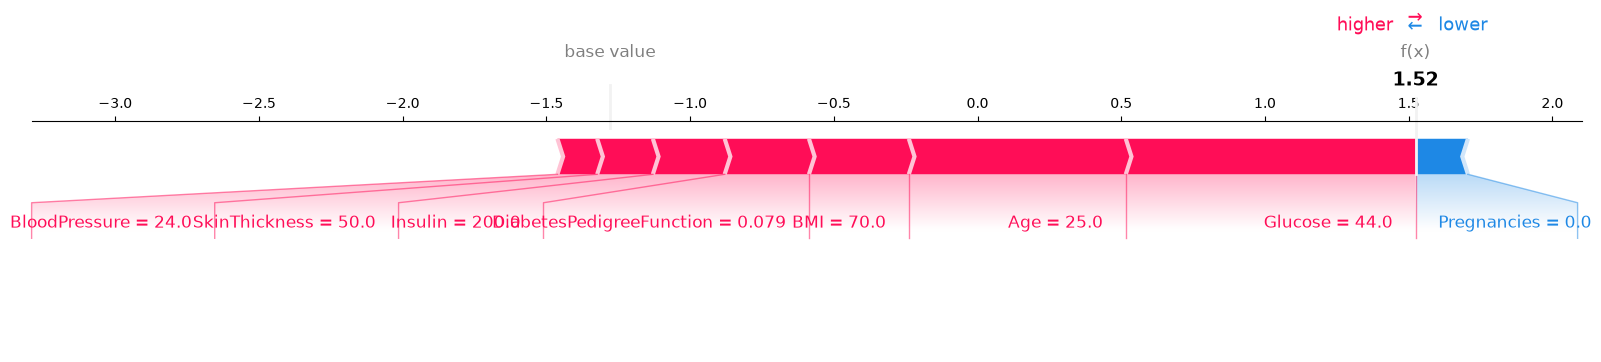

In [ ]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    sample,
    feature_names=X.columns,
    matplotlib=True
)